# Notebook 3: Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on the preprocessed FIFA World Cup match dataset. The goal is to understand the structure, distributions, and relationships in the data before modeling, and to surface insights that inform feature selection and modeling choices.

The analysis covers the five EDA areas required for the project milestone:

1. **Distribution analysis** of key features and the target variable
2. **Correlation analysis** between features and the target
3. **Relationships and insights** (home advantage, upsets, scoring patterns)
4. **Feature importance assessment** (which features carry predictive signal)
5. **Time-based patterns** across eras

**Data source:** `matches_preprocessed_readable.csv`, produced by Notebook 2 (preprocessing). This file keeps human-readable columns and the score-based columns needed for analysis, and contains matches from 1994 onward after the year restriction applied in preprocessing.

**Note on data leakage:** the modeling split in Notebook 2 is temporal (train = years before 2022, test = 2022 onward). For descriptive EDA we explore the full readable dataset, but for any analysis that directly informs modeling choices (correlation and feature importance), we also report the training-only view so we can confirm patterns are not driven by the held-out test period.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

# Consistent plot styling
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.options.display.float_format = "{:.3f}".format

## Load the Preprocessed Dataset

We load the readable EDA dataset created in the preprocessing notebook.

In [2]:
# Locate the processed data directory
DATA_DIR = Path("../data")
if not (DATA_DIR / "processed" / "matches_preprocessed_readable.csv").exists():
    DATA_DIR = Path("./data")

PROCESSED_DIR = DATA_DIR / "processed"

eda_df = pd.read_csv(PROCESSED_DIR / "matches_preprocessed_readable.csv", parse_dates=["date"])

print("EDA dataset shape:", eda_df.shape)
print("Year range:", eda_df["year"].min(), "-", eda_df["year"].max())
eda_df.head()

EDA dataset shape: (29904, 20)
Year range: 1994 - 2026


,date,year,home_team,away_team,home_team_clean,away_team_clean,home_score,away_score,match_result,tournament,city,country,neutral,is_world_cup,home_elo,away_elo,elo_diff,goal_diff,abs_goal_diff,total_goals
0,1994-01-02,1994,Barbados,Grenada,Barbados,Grenada,0,0,draw,Friendly,Bridgetown,Barbados,False,False,1248.000,1363.000,-115.000,0,0,0
1,1994-01-02,1994,Ghana,Egypt,Ghana,Egypt,2,1,home_win,Friendly,Accra,Ghana,False,False,1622.000,1663.000,-41.000,1,1,3
2,1994-01-05,1994,Mali,Burkina Faso,Mali,Burkina Faso,1,1,draw,Friendly,Bamako,Mali,False,False,1501.000,1324.000,177.000,0,0,2
3,1994-01-09,1994,Mauritania,Mali,Mauritania,Mali,1,3,away_win,Friendly,Nouakchott,Mauritania,False,False,1077.000,1501.000,-424.000,-2,2,4
4,1994-01-11,1994,Thailand,Nigeria,Thailand,Nigeria,1,1,draw,Friendly,Bangkok,Thailand,False,False,1354.000,1622.000,-268.000,0,0,2


In [3]:
# Quick structural overview: dtypes and non-null counts
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29904 entries, 0 to 29903
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             29904 non-null  datetime64[ns]
 1   year             29904 non-null  int64         
 2   home_team        29904 non-null  object        
 3   away_team        29904 non-null  object        
 4   home_team_clean  29904 non-null  object        
 5   away_team_clean  29904 non-null  object        
 6   home_score       29904 non-null  int64         
 7   away_score       29904 non-null  int64         
 8   match_result     29904 non-null  object        
 9   tournament       29904 non-null  object        
 10  city             29904 non-null  object        
 11  country          29904 non-null  object        
 12  neutral          29904 non-null  bool          
 13  is_world_cup     29904 non-null  bool          
 14  home_elo         28380 non-null  float

### Data quality: spurious zero Elo ratings

A check of the Elo columns surfaces a small number of rows with an Elo of exactly 0. No rating system places a team at 0 (unrated teams enter around 1300 to 1500), so these are missing ratings that were filled with 0 instead of NaN. All of them are 2026 matches involving Moldova, where the leakage-aware Elo merge in Notebook 2 found no rating to attach. Because 2026 is the forecast target period, a 0 is not harmless: it produces an `elo_diff` near the dataset minimum (Moldova vs Bulgaria becomes 0 - 1452 = -1452) and mis-rates the team as one of the weakest in the data. We convert these zeros to NaN and null the corresponding `elo_diff` so the missingness propagates correctly. The root-cause fix belongs upstream in the Notebook 2 Elo merge; this cell is a defensive guard so the EDA and any downstream forecast are not contaminated.

In [4]:
# Data quality fix: a few rows carry an Elo of exactly 0, which is not a real
# rating. All trace to 2026 matches where the Elo merge returned no value
# (Moldova). Since 2026 is the forecast period, a 0 yields an elo_diff near the
# dataset minimum and badly mis-rates the team. Convert the sentinel 0s to NaN
# and null elo_diff for those rows so the gap propagates as missing. We null
# elo_diff rather than recompute it, to preserve the leakage-aware diff from
# Notebook 2 (its non-null count is intentionally lower than the raw Elo columns).
zero_elo_mask = (eda_df["home_elo"] == 0) | (eda_df["away_elo"] == 0)
print("Rows with a zero Elo before cleaning:", int(zero_elo_mask.sum()))
print(eda_df.loc[zero_elo_mask,
                 ["year", "home_team", "away_team", "home_elo", "away_elo", "elo_diff"]])

eda_df.loc[eda_df["home_elo"] == 0, "home_elo"] = np.nan
eda_df.loc[eda_df["away_elo"] == 0, "away_elo"] = np.nan
eda_df.loc[zero_elo_mask, "elo_diff"] = np.nan

print("\nZero-Elo rows after cleaning:",
      int(((eda_df["home_elo"] == 0) | (eda_df["away_elo"] == 0)).sum()))
print("New home_elo min:", eda_df["home_elo"].min())
print("New away_elo min:", eda_df["away_elo"].min())
print("New elo_diff min:", eda_df["elo_diff"].min())

Rows with a zero Elo before cleaning: 4
       year home_team  away_team  home_elo  away_elo  elo_diff
29629  2026   Moldova  Lithuania     0.000  1276.000 -1276.000
29701  2026    Cyprus    Moldova  1302.000     0.000  1302.000
29827  2026   Moldova   Bulgaria     0.000  1452.000 -1452.000
29881  2026   Armenia    Moldova  1389.000     0.000  1389.000

Zero-Elo rows after cleaning: 0
New home_elo min: 497.0
New away_elo min: 497.0
New elo_diff min: -1229.0


In [5]:
# Define the training-only view for leakage-sensitive analyses
# The modeling split in Notebook 2 uses year < 2022 as training
train_eda_df = eda_df[eda_df["year"] < 2022].copy()

print("Full EDA rows:", eda_df.shape[0])
print("Training-only rows (year < 2022):", train_eda_df.shape[0])
print("Test-period rows (year >= 2022):", (eda_df["year"] >= 2022).sum())

Full EDA rows: 29904
Training-only rows (year < 2022): 25334
Test-period rows (year >= 2022): 4570


---
## 1. Distribution Analysis

We examine the distribution of the target variable and the key numeric features. Understanding these distributions tells us about class balance, skewness, and the spread of our strongest predictors before modeling.

### 1.1 Target variable: match result

Match result counts:
match_result
home_win    14511
away_win     8424
draw         6969
Name: count, dtype: int64

Match result proportions:
match_result
home_win   0.485
away_win   0.282
draw       0.233
Name: proportion, dtype: float64


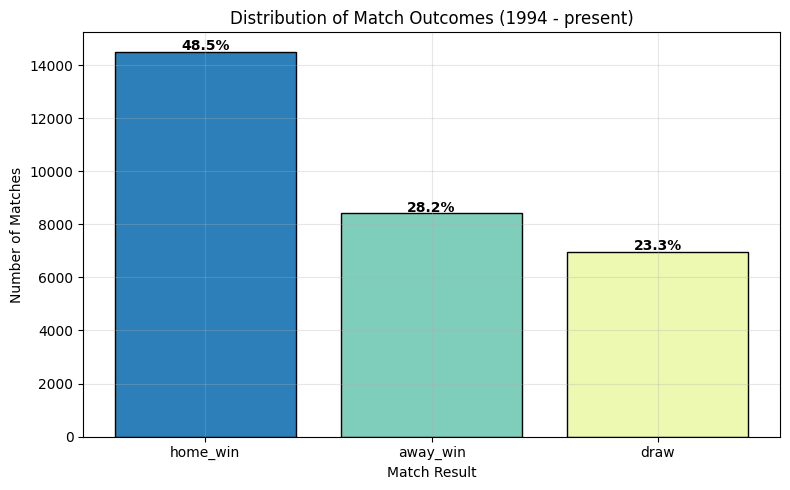

In [6]:
# Distribution of the three-class target
target_counts = eda_df["match_result"].value_counts()
target_props = eda_df["match_result"].value_counts(normalize=True)

print("Match result counts:")
print(target_counts)
print("\nMatch result proportions:")
print(target_props)

fig, ax = plt.subplots()
ax.bar(target_counts.index, target_counts.values,
       color=["#2c7fb8", "#7fcdbb", "#edf8b1"], edgecolor="black")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 50, f"{target_props.iloc[i]*100:.1f}%", ha="center", fontweight="bold")
ax.set_xlabel("Match Result")
ax.set_ylabel("Number of Matches")
ax.set_title("Distribution of Match Outcomes (1994 - present)")
plt.tight_layout()
plt.show()

**Interpretation:** Home wins are the most common outcome, away wins second, and draws the least frequent class. This class imbalance is characteristic of international soccer: the home/listed-first team has an advantage, and draws are structurally less common than decisive results. This imbalance matters for modeling: a naive baseline that always predicts the majority class (home win) will set the accuracy bar we must beat, and we should report per-class metrics (precision/recall) rather than accuracy alone, since draws will be the hardest class to predict.

### 1.2 Elo differential (strongest expected feature)

count   27605.000
mean       22.239
std       277.801
min     -1229.000
25%      -153.000
50%        25.000
75%       200.000
max      1217.000
Name: elo_diff, dtype: float64


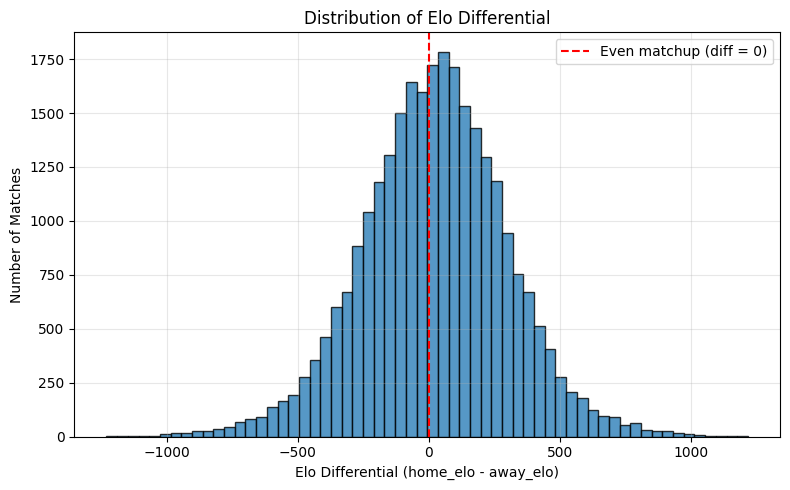

In [7]:
# elo_diff = home_elo - away_elo
elo_diff_clean = eda_df["elo_diff"].dropna()

print(elo_diff_clean.describe())

fig, ax = plt.subplots()
ax.hist(elo_diff_clean, bins=60, color="#2c7fb8", edgecolor="black", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Even matchup (diff = 0)")
ax.set_xlabel("Elo Differential (home_elo - away_elo)")
ax.set_ylabel("Number of Matches")
ax.set_title("Distribution of Elo Differential")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The Elo differential is approximately symmetric and centered near zero, which is expected: for every strong-vs-weak matchup there is a corresponding weak-vs-strong one when teams are listed as home or away. The spread shows that many matches feature meaningful Elo gaps, which is encouraging for prediction: when the gap is large, the outcome should be more predictable. The symmetry also acts as a sanity check that the leakage-aware Elo merge in preprocessing behaved sensibly.

### 1.3 Home and away Elo ratings

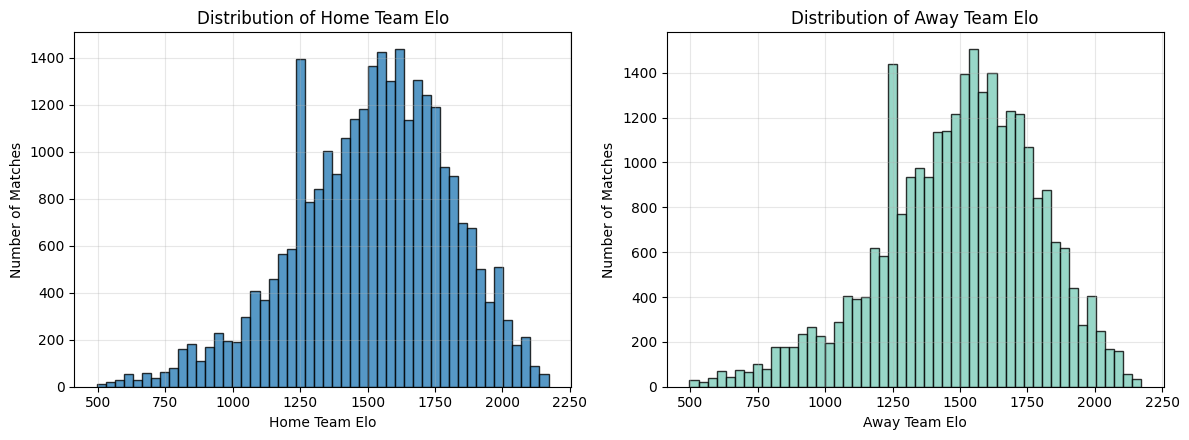

Home Elo summary:
count   28378.000
mean     1515.993
std       287.427
min       497.000
25%      1325.000
50%      1540.000
75%      1721.000
max      2171.000
Name: home_elo, dtype: float64

Away Elo summary:
count   28276.000
mean     1494.869
std       291.093
min       497.000
25%      1309.000
50%      1523.000
75%      1702.000
max      2171.000
Name: away_elo, dtype: float64


In [8]:
# Distributions of the raw Elo ratings for home and away teams
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(eda_df["home_elo"].dropna(), bins=50, color="#2c7fb8", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Home Team Elo")
axes[0].set_ylabel("Number of Matches")
axes[0].set_title("Distribution of Home Team Elo")

axes[1].hist(eda_df["away_elo"].dropna(), bins=50, color="#7fcdbb", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Away Team Elo")
axes[1].set_ylabel("Number of Matches")
axes[1].set_title("Distribution of Away Team Elo")

plt.tight_layout()
plt.show()

print("Home Elo summary:")
print(eda_df["home_elo"].describe())
print("\nAway Elo summary:")
print(eda_df["away_elo"].describe())

**Interpretation:** Both home and away Elo ratings are roughly bell-shaped and cover a wide range, reflecting the mix of strong and weak national teams in the dataset, with a realistic rating floor after the zero-Elo cleaning above rather than an artificial spike at 0. The two distributions look similar, which is expected since most teams appear as both home and away across different matches.

### 1.4 Goals: total goals and goal differential

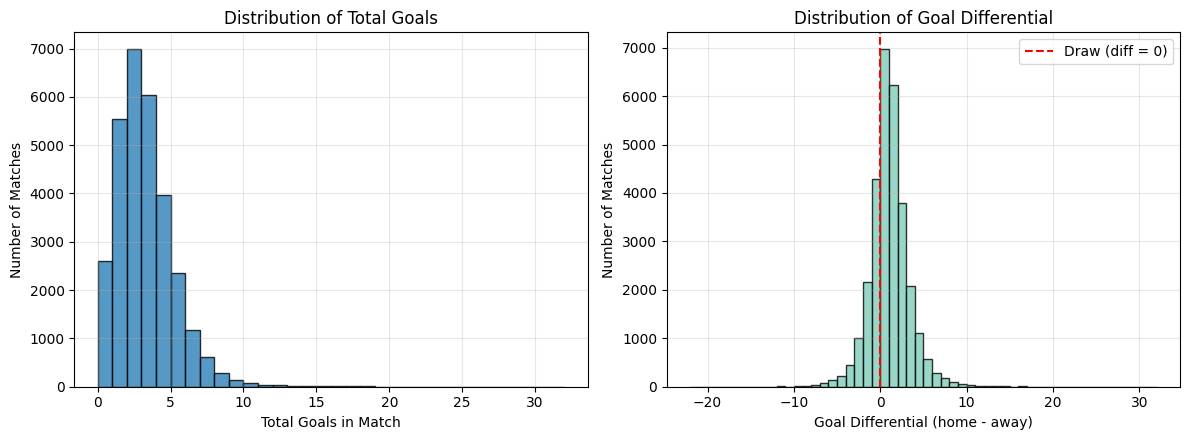

Total goals summary:
count   29904.000
mean        2.769
std         1.993
min         0.000
25%         1.000
50%         2.000
75%         4.000
max        31.000
Name: total_goals, dtype: float64


In [9]:
# Score-based distributions. These are outcome-derived (not model features),
# but they characterize the data and motivate the difficulty of predicting draws.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(eda_df["total_goals"], bins=range(0, int(eda_df["total_goals"].max()) + 2),
             color="#2c7fb8", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Total Goals in Match")
axes[0].set_ylabel("Number of Matches")
axes[0].set_title("Distribution of Total Goals")

axes[1].hist(eda_df["goal_diff"], bins=range(int(eda_df["goal_diff"].min()) - 1,
             int(eda_df["goal_diff"].max()) + 2),
             color="#7fcdbb", edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Draw (diff = 0)")
axes[1].set_xlabel("Goal Differential (home - away)")
axes[1].set_ylabel("Number of Matches")
axes[1].set_title("Distribution of Goal Differential")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Total goals summary:")
print(eda_df["total_goals"].describe())

**Interpretation:** Total goals is right-skewed, peaking around 2-3 goals per match with a long tail of high-scoring games, consistent with the low-scoring nature of soccer. The goal differential distribution is centered and roughly symmetric around zero, with the zero draws prominent. The clustering of outcomes near a one-goal margin is precisely why draws and narrow wins are hard to separate: many matches are decided by a single goal that could easily have gone the other way.

---
## 2. Correlation Analysis

We examine how the numeric features relate to each other and to the outcome. Because the target is categorical, we use two complementary views: (a) a correlation heatmap among numeric features (including a numeric encoding of the result), and (b) feature distributions grouped by outcome class.

In [10]:
# Encode the result as an ordinal for correlation purposes:
# away_win = -1, draw = 0, home_win = +1. This ordering reflects the home-perspective outcome and lets us correlate elo_diff with result direction
result_to_ordinal = {"away_win": -1, "draw": 0, "home_win": 1}
eda_df["result_ordinal"] = eda_df["match_result"].map(result_to_ordinal)

corr_cols = ["home_elo", "away_elo", "elo_diff", "goal_diff", "total_goals", "result_ordinal"]
corr_matrix = eda_df[corr_cols].corr()

print("Correlation matrix:")
print(corr_matrix)

Correlation matrix:
                home_elo  away_elo  elo_diff  goal_diff  total_goals  \
home_elo           1.000     0.533     0.472      0.228       -0.033   
away_elo           0.533     1.000    -0.495     -0.303       -0.146   
elo_diff           0.472    -0.495     1.000      0.589        0.122   
goal_diff          0.228    -0.303     0.589      1.000        0.235   
total_goals       -0.033    -0.146     0.122      0.235        1.000   
result_ordinal     0.216    -0.254     0.500      0.772        0.085   

                result_ordinal  
home_elo                 0.216  
away_elo                -0.254  
elo_diff                 0.500  
goal_diff                0.772  
total_goals              0.085  
result_ordinal           1.000  


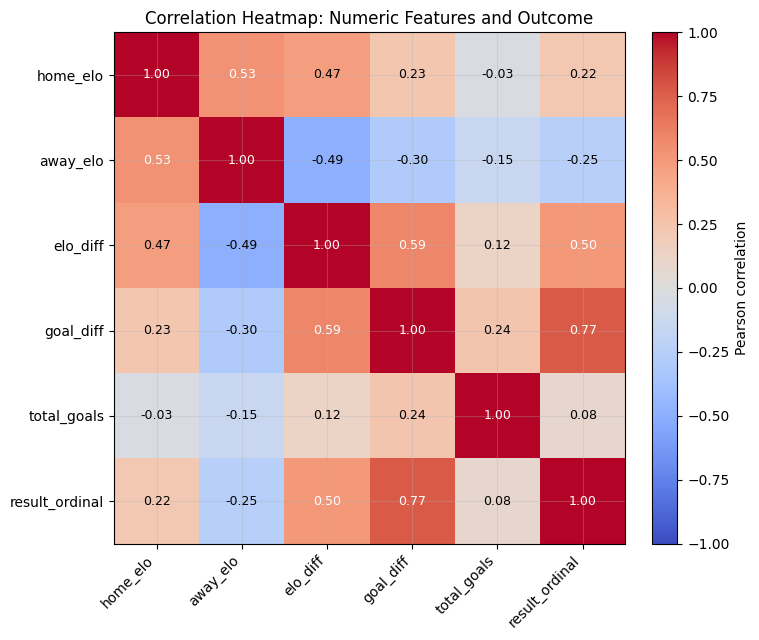

In [11]:
# Heatmap of the correlation matrix
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

# Annotate each cell with its value
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black", fontsize=9)

ax.set_title("Correlation Heatmap: Numeric Features and Outcome")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson correlation")
plt.tight_layout()
plt.show()

**Interpretation:** The most important relationship is between `elo_diff` and the outcome (`result_ordinal`): a positive correlation confirms that when the home team is rated higher, home wins become more likely. This validates `elo_diff` as our primary predictive feature. As expected, `home_elo` and `away_elo` are strongly related to `elo_diff` by construction (it is their difference), so including all three introduces redundancy; a model using `elo_diff` alone captures most of the signal. The score-based columns (`goal_diff`, `total_goals`) correlate with the outcome but are excluded from modeling because they are only known after the match.

In [12]:
# Training-only correlation check to confirm the elo_diff -> outcome signal
train_eda_df["result_ordinal"] = train_eda_df["match_result"].map(result_to_ordinal)
train_corr = train_eda_df[["elo_diff", "result_ordinal"]].corr().iloc[0, 1]
full_corr = eda_df[["elo_diff", "result_ordinal"]].corr().iloc[0, 1]

print(f"Correlation(elo_diff, outcome) - full data:      {full_corr:.4f}")
print(f"Correlation(elo_diff, outcome) - training only:   {train_corr:.4f}")
print("\nThe relationship holds in the training subset, so it is not driven by the test period.")

Correlation(elo_diff, outcome) - full data:      0.5005
Correlation(elo_diff, outcome) - training only:   0.4931

The relationship holds in the training subset, so it is not driven by the test period.


### 2.1 Elo differential grouped by outcome

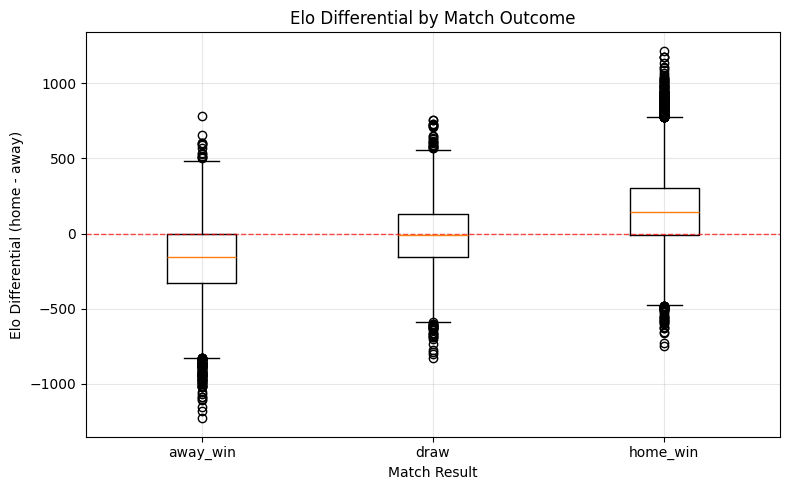

Median elo_diff by outcome:
match_result
away_win   -158.000
draw        -12.000
home_win    146.000
Name: elo_diff, dtype: float64


In [13]:
# Box plot of elo_diff for each outcome class shows whether the feature separates the three outcomes
classes = ["away_win", "draw", "home_win"]
data_by_class = [eda_df.loc[eda_df["match_result"] == c, "elo_diff"].dropna() for c in classes]

fig, ax = plt.subplots()
ax.boxplot(data_by_class, tick_labels=classes)
ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Match Result")
ax.set_ylabel("Elo Differential (home - away)")
ax.set_title("Elo Differential by Match Outcome")
plt.tight_layout()
plt.show()

print("Median elo_diff by outcome:")
print(eda_df.groupby("match_result")["elo_diff"].median())

**Interpretation:** This is one of the most informative plots for modeling. Home wins tend to have a positive Elo differential (the home team was the stronger side), away wins a negative one, and draws sit in between, near zero. The separation between home wins and away wins is clear, which is promising. However, the draw distribution overlaps heavily with both, confirming the earlier expectation that draws will be the hardest class to predict: an even Elo matchup can end in a draw, a narrow home win, or a narrow away win.

---
## 3. Relationships and Insights

Here we investigate substantive soccer questions that affect modeling: home advantage, the effect of neutral-site matches, and how often upsets occur.

### 3.1 Home advantage and neutral sites

Outcome proportions by neutral-site status:
match_result  away_win  draw  home_win
neutral                               
False            0.259 0.232     0.509
True             0.340 0.235     0.425


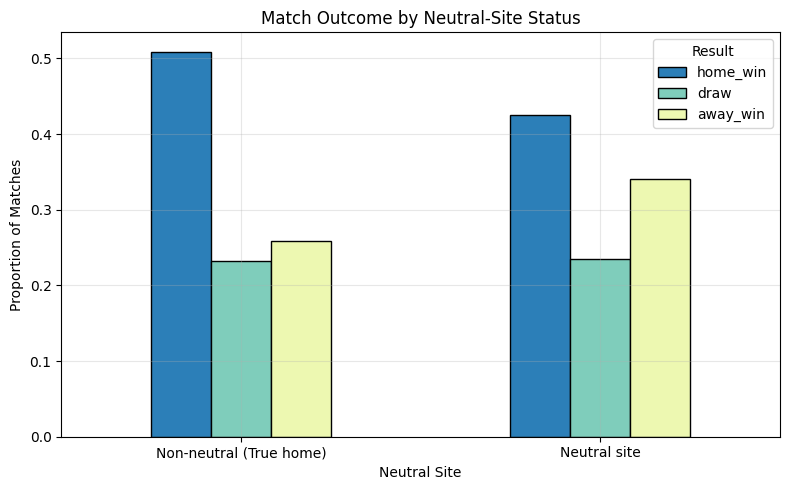

In [14]:
# Outcome distribution split by whether the match was played at a neutral site
# Home advantage should weaken or disappear at neutral venues
neutral_outcomes = (
    eda_df.groupby("neutral")["match_result"]
    .value_counts(normalize=True)
    .unstack()
)
print("Outcome proportions by neutral-site status:")
print(neutral_outcomes)

fig, ax = plt.subplots()
neutral_outcomes.loc[:, ["home_win", "draw", "away_win"]].plot(
    kind="bar", ax=ax, color=["#2c7fb8", "#7fcdbb", "#edf8b1"], edgecolor="black"
)
ax.set_xlabel("Neutral Site")
ax.set_ylabel("Proportion of Matches")
ax.set_title("Match Outcome by Neutral-Site Status")
ax.set_xticklabels(["Non-neutral (True home)", "Neutral site"], rotation=0)
ax.legend(title="Result")
plt.tight_layout()
plt.show()

**Interpretation:** At non-neutral venues the home team wins a clearly larger share of matches, confirming a real home advantage. At neutral sites the home-win proportion drops and away wins rise, since the nominal "home" team no longer enjoys familiar conditions or crowd support. This is directly relevant to the 2026 World Cup: the host nations (USA, Canada, Mexico) play true home matches, while most tournament matches are effectively neutral. The `neutral` flag is therefore a sensible categorical feature for the model.

### 3.2 Upset frequency

Upset rate by absolute Elo gap (draw counts as favorite not winning):
elo_gap_bin
0-50      0.621
50-100    0.563
100-150   0.526
150-200   0.473
200-300   0.393
300+      0.217
Name: is_upset, dtype: float64


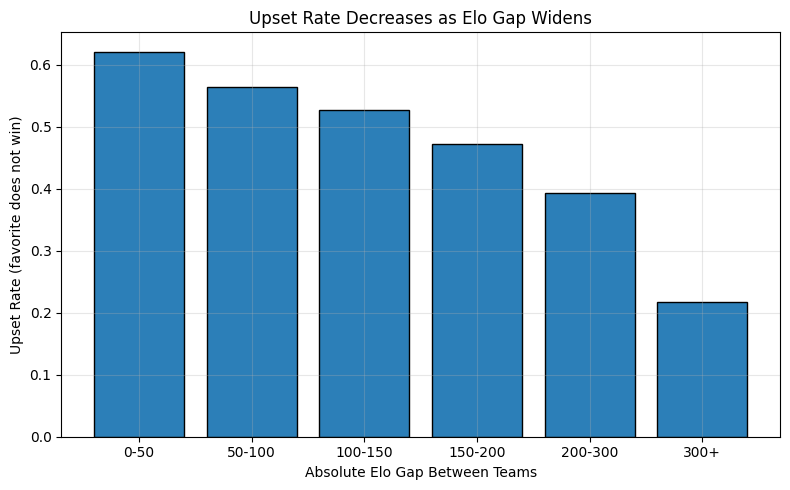

In [15]:
# An "upset" is when the team with the higher Elo does NOT win
# We restrict to matches with a non-trivial Elo gap to make "favorite" meaningful
matches_with_elo = eda_df.dropna(subset=["elo_diff"]).copy()

# Favorite = positive elo_diff means home favored; negative means away favored
# Vectorized so the column is numeric (float) rather than object: home-favored
# upset = home did not win; away-favored upset = away did not win; exactly even
# is undefined (NaN)
matches_with_elo["is_upset"] = np.select(
    [matches_with_elo["elo_diff"] > 0, matches_with_elo["elo_diff"] < 0],
    [(matches_with_elo["match_result"] != "home_win"),
     (matches_with_elo["match_result"] != "away_win")],
    default=np.nan,
).astype("float")

# Bin by absolute Elo gap and compute upset rate
matches_with_elo["abs_elo_gap"] = matches_with_elo["elo_diff"].abs()
bins = [0, 50, 100, 150, 200, 300, 2000]
labels = ["0-50", "50-100", "100-150", "150-200", "200-300", "300+"]
matches_with_elo["elo_gap_bin"] = pd.cut(matches_with_elo["abs_elo_gap"], bins=bins, labels=labels)

upset_rate = matches_with_elo.groupby("elo_gap_bin", observed=True)["is_upset"].mean()
print("Upset rate by absolute Elo gap (draw counts as favorite not winning):")
print(upset_rate)

fig, ax = plt.subplots()
ax.bar(upset_rate.index.astype(str), upset_rate.values, color="#2c7fb8", edgecolor="black")
ax.set_xlabel("Absolute Elo Gap Between Teams")
ax.set_ylabel("Upset Rate (favorite does not win)")
ax.set_title("Upset Rate Decreases as Elo Gap Widens")
plt.tight_layout()
plt.show()

**Interpretation:** The upset rate falls steadily as the Elo gap widens. In closely matched games (small gap) the favorite frequently fails to win, often because the match ends in a draw, while in lopsided matchups the favorite wins the large majority of the time. This monotonic relationship is strong evidence that `elo_diff` carries genuine predictive signal, and it also sets a realistic ceiling on accuracy: close matches are inherently noisy and partly unpredictable, so no model should be expected to classify them perfectly.

---
## 4. Feature Importance Assessment

Before modeling, we get a rough sense of which features carry signal by (a) examining how outcome proportions shift across binned Elo differential, and (b) fitting a quick multinomial logistic regression and inspecting standardized coefficient magnitudes. These are preliminary diagnostics, not final model results.

### 4.1 Outcome shift across Elo differential bins

Outcome proportions by Elo differential bin:
match_result  home_win  draw  away_win
elo_diff_bin                          
<-200            0.161 0.231     0.608
-200..-100       0.318 0.302     0.380
-100..-50        0.360 0.303     0.337
-50..50          0.459 0.285     0.257
50..100          0.528 0.272     0.199
100..200         0.606 0.252     0.142
>200             0.787 0.147     0.066


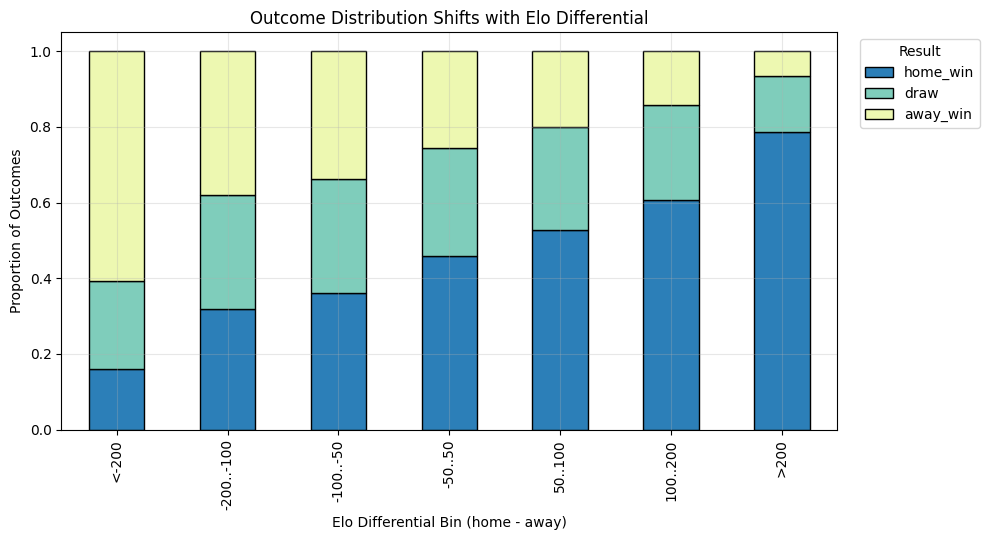

In [16]:
# If a feature has signal, the outcome distribution should change across its bins
elo_bins = [-2000, -200, -100, -50, 50, 100, 200, 2000]
elo_bin_labels = ["<-200", "-200..-100", "-100..-50", "-50..50", "50..100", "100..200", ">200"]
matches_with_elo["elo_diff_bin"] = pd.cut(matches_with_elo["elo_diff"], bins=elo_bins, labels=elo_bin_labels)

outcome_by_bin = (
    matches_with_elo.groupby("elo_diff_bin", observed=True)["match_result"]
    .value_counts(normalize=True)
    .unstack()
    .loc[:, ["home_win", "draw", "away_win"]]
)
print("Outcome proportions by Elo differential bin:")
print(outcome_by_bin)

fig, ax = plt.subplots(figsize=(10, 5.5))
outcome_by_bin.plot(kind="bar", stacked=True, ax=ax,
                    color=["#2c7fb8", "#7fcdbb", "#edf8b1"], edgecolor="black")
ax.set_xlabel("Elo Differential Bin (home - away)")
ax.set_ylabel("Proportion of Outcomes")
ax.set_title("Outcome Distribution Shifts with Elo Differential")
ax.legend(title="Result", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** The outcome mix shifts strongly and smoothly across Elo bins. When the home team is heavily favored (large positive differential) home wins dominate; when the away team is heavily favored home wins collapse and away wins dominate. Draws are most common in the central, evenly matched bin and shrink toward the extremes. This clean gradient is exactly what we want to see: `elo_diff` is a strong, monotonic predictor of the outcome.

### 4.2 Quick multinomial logistic regression (coefficient magnitudes)

Standardized logistic regression coefficients (per outcome class):
          home_elo  away_elo  elo_diff
away_win    -0.251     0.274    -0.534
draw         0.022     0.038    -0.017
home_win     0.229    -0.311     0.551

Mean absolute coefficient (rough feature importance):
elo_diff   0.367
away_elo   0.208
home_elo   0.167
dtype: float64


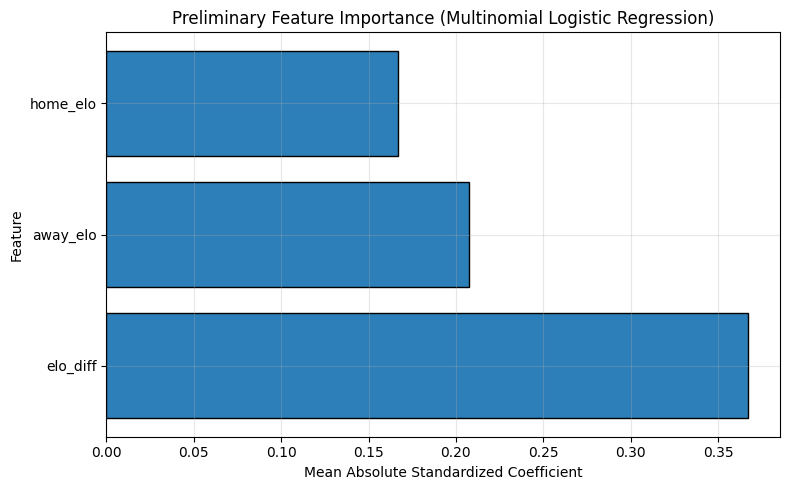

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Use the leakage-safe features only, on the training subset, as a preliminary importance probe
# This mirrors the modeling feature set from Notebook 2
probe_df = train_eda_df.dropna(subset=["home_elo", "away_elo", "elo_diff"]).copy()

probe_features = ["home_elo", "away_elo", "elo_diff"]
X_probe = probe_df[probe_features].values
y_probe = probe_df["match_result"].values

scaler = StandardScaler()
X_probe_std = scaler.fit_transform(X_probe)

probe_model = LogisticRegression(max_iter=1000)
probe_model.fit(X_probe_std, y_probe)

# Coefficient magnitude per class. Larger absolute value = stronger influence
coef_df = pd.DataFrame(
    probe_model.coef_,
    columns=probe_features,
    index=probe_model.classes_
)
print("Standardized logistic regression coefficients (per outcome class):")
print(coef_df)

# Average absolute coefficient across classes as a rough importance score
importance = coef_df.abs().mean(axis=0).sort_values(ascending=False)
print("\nMean absolute coefficient (rough feature importance):")
print(importance)

fig, ax = plt.subplots()
ax.barh(importance.index, importance.values, color="#2c7fb8", edgecolor="black")
ax.set_xlabel("Mean Absolute Standardized Coefficient")
ax.set_ylabel("Feature")
ax.set_title("Preliminary Feature Importance (Multinomial Logistic Regression)")
plt.tight_layout()
plt.show()

**Interpretation:** The standardized coefficients confirm that the Elo-based features dominate the prediction. Note that because `elo_diff` is a linear combination of `home_elo` and `away_elo`, the model spreads signal across the three correlated features; in the final modeling notebook we may prefer `elo_diff` alone (or `home_elo` and `away_elo` without the explicit difference) to reduce redundancy. This is a preliminary probe on training data only, intended to guide feature selection rather than to report final performance.

---
## 5. Time-Based Patterns

The dataset spans 1994 to the present. We check whether match characteristics have drifted over time, which informs whether the year restriction in preprocessing is appropriate and whether recent matches are more representative for predicting 2026.

### 5.1 Matches per year

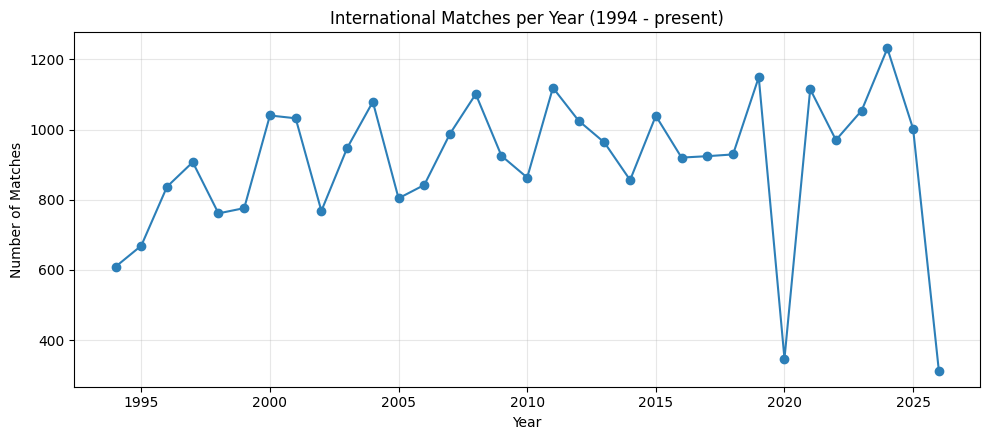

Total matches: 29904
Median matches per year: 929


In [18]:
matches_per_year = eda_df.groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(matches_per_year.index, matches_per_year.values, marker="o", color="#2c7fb8")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Matches")
ax.set_title("International Matches per Year (1994 - present)")
plt.tight_layout()
plt.show()

print("Total matches:", matches_per_year.sum())
print("Median matches per year:", int(matches_per_year.median()))

**Interpretation:** The number of international matches per year is substantial and fairly stable across the period, with the expected dips and peaks around tournament cycles. The healthy per-year sample size supports the 1994 cutoff chosen in preprocessing: we retain a large, modern dataset without reaching back into eras that look very different from today's game.

### 5.2 Average goals per match over time

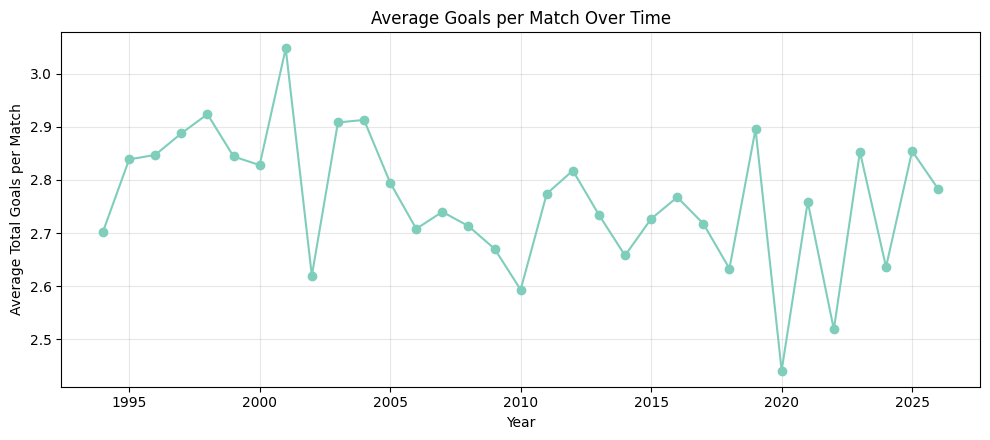

count   33.000
mean     2.762
std      0.126
min      2.441
25%      2.703
50%      2.767
75%      2.847
max      3.047
Name: total_goals, dtype: float64


In [19]:
goals_per_year = eda_df.groupby("year")["total_goals"].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(goals_per_year.index, goals_per_year.values, marker="o", color="#7fcdbb")
ax.set_xlabel("Year")
ax.set_ylabel("Average Total Goals per Match")
ax.set_title("Average Goals per Match Over Time")
plt.tight_layout()
plt.show()

print(goals_per_year.describe())

**Interpretation:** Average goals per match is relatively stable over the modern era, fluctuating within a narrow band rather than trending sharply. This stability is reassuring: scoring behavior in 1994 is broadly comparable to today, so treating the post-1994 period as one regime for modeling is defensible. Had we seen a strong trend, it would argue for an even more recent cutoff or for including year as a feature.

### 5.3 Home-win rate over time

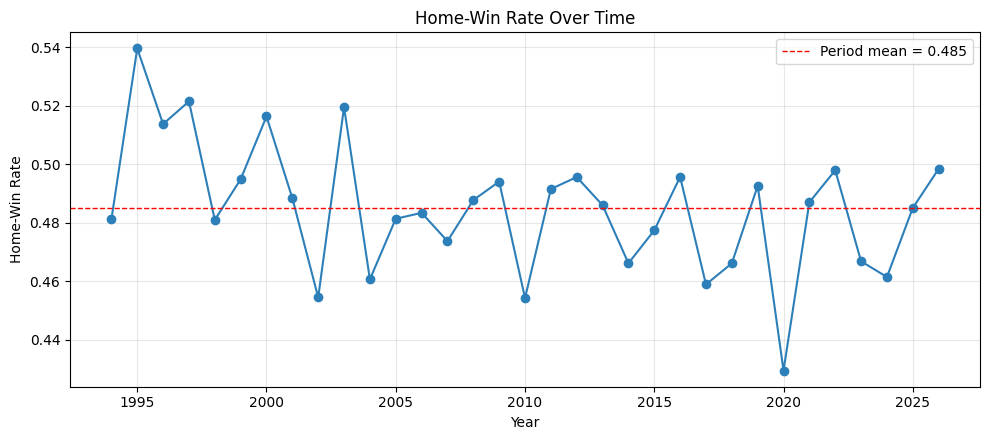

In [20]:
home_win_rate = (
    eda_df.assign(is_home_win=(eda_df["match_result"] == "home_win").astype(int))
    .groupby("year")["is_home_win"].mean()
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(home_win_rate.index, home_win_rate.values, marker="o", color="#2c7fb8")
ax.axhline(home_win_rate.mean(), color="red", linestyle="--", linewidth=1,
           label=f"Period mean = {home_win_rate.mean():.3f}")
ax.set_xlabel("Year")
ax.set_ylabel("Home-Win Rate")
ax.set_title("Home-Win Rate Over Time")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The home-win rate hovers around its long-run mean with year-to-year variation but no dramatic structural break. The notable consideration for 2026 prediction is that a growing share of recent matches are played at neutral sites (major tournaments, qualifiers at neutral venues), which can dampen the raw home-win rate; this reinforces why the `neutral` flag belongs in the model.

---
## 6. EDA Summary and Modeling Implications

**Key findings:**

1. **Class imbalance in the target.** Home wins are most frequent, away wins second, and draws least common. A majority-class baseline (always predict home win) sets the accuracy floor, and draws will be the hardest class to predict. We will report per-class precision and recall, not just accuracy.

2. **Elo differential is the dominant feature.** It is approximately symmetric around zero, separates home wins from away wins clearly, and drives a smooth, monotonic shift in outcome proportions. The upset-rate analysis confirms its signal: favorites win more often as the Elo gap widens.

3. **Feature redundancy.** `home_elo`, `away_elo`, and `elo_diff` are strongly related by construction. The final model may use `elo_diff` alone, or the two raw ratings, to avoid redundancy.

4. **Home advantage is real but conditional.** Home teams win more at non-neutral venues; the advantage shrinks at neutral sites. The `neutral` flag is a justified feature, especially given the 2026 host-nation context.

5. **The modern era is reasonably stable.** Matches per year, average goals, and home-win rate are steady across 1994-present, supporting the preprocessing cutoff and the decision to treat this period as a single regime.

6. **Draws cap achievable accuracy.** Evenly matched games are genuinely noisy and frequently end in draws or one-goal margins, so a realistic model should be evaluated against the imbalanced baseline rather than an expectation of near-perfect accuracy.

**Implications for modeling (Notebook 4):**

- Baseline: majority-class classifier (predict home win).
- Improvements: multinomial logistic regression and a tree-based model (e.g., gradient boosting), both using Elo-based features plus `neutral` and tournament context.
- Evaluation: accuracy against the majority baseline, plus per-class precision/recall and a confusion matrix, with particular attention to the draw class.
- Validation: respect the temporal split (train on pre-2022, evaluate on 2022 onward) to mimic forecasting the 2026 tournament.